In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = pd.read_csv('C:/Users/nigam/Downloads/Tesla.csv - Tesla.csv.csv')

In [3]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


In [5]:
df= df[['Close']]
print(df.head())

       Close
0  23.889999
1  23.830000
2  21.959999
3  19.200001
4  16.110001


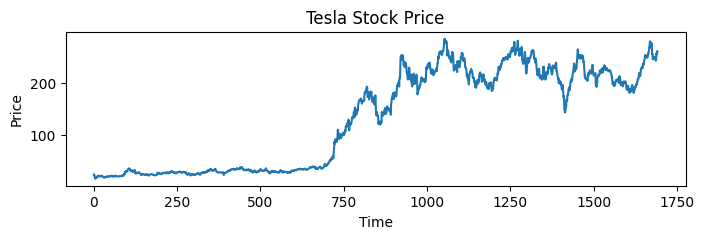

In [8]:
plt.figure(figsize=(8,2))
plt.plot(df['Close'])
plt.title("Tesla Stock Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [10]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_df = scaler.fit_transform(df)

In [12]:
X = []
y = []

for i in range(60, len(scaled_df)):
    X.append(scaled_df[i-60:i])
    y.append(scaled_df[i])

X = np.array(X)
y = np.array(y)

In [13]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [14]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/10

41/41 [==============================] - 7s 47ms/step - loss: 0.0250 - val_loss: 0.0057
Epoch 2/10
41/41 [==============================] - 1s 35ms/step - loss: 0.0017 - val_loss: 0.0033
Epoch 3/10
41/41 [==============================] - 1s 33ms/step - loss: 0.0014 - val_loss: 0.0028
Epoch 4/10
41/41 [==============================] - 1s 33ms/step - loss: 0.0013 - val_loss: 0.0027
Epoch 5/10
41/41 [==============================] - 1s 34ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 6/10
41/41 [==============================] - 2s 40ms/step - loss: 0.0011 - val_loss: 0.0023
Epoch 7/10
41/41 [==============================] - 2s 38ms/step - loss: 0.0012 - val_loss: 0.0022
Epoch 8/10
41/41 [==============================] - 2s 40ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 9/10
41/41 [==============================] - 2s 40ms/step - loss: 0.0010 - val_loss: 0.0029
Epoch 10/10
41/41 [==============================] - 2s 37ms/step - loss: 0.0010 - val_loss: 0.0017


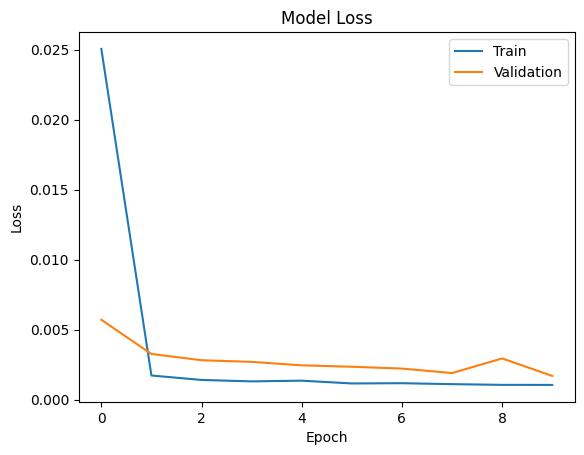

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])
plt.show()

In [17]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

11/11 [==============================] - 1s 9ms/step


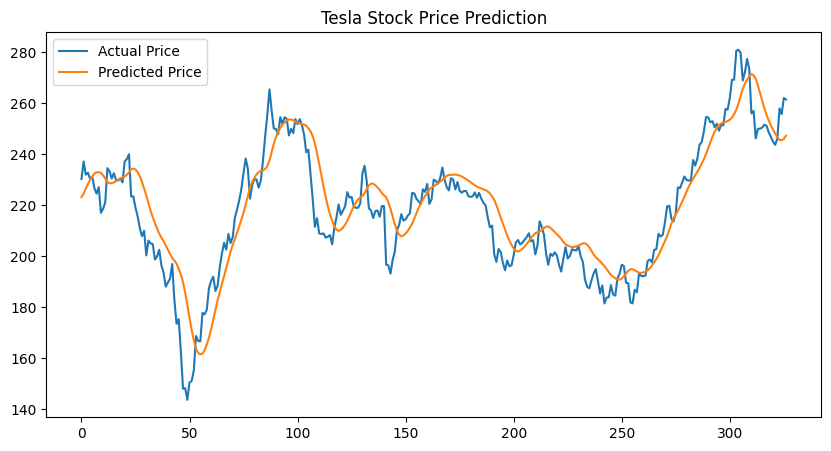

In [18]:
plt.figure(figsize=(10,5))

plt.plot(y_test, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.legend()
plt.title("Tesla Stock Price Prediction")
plt.show()

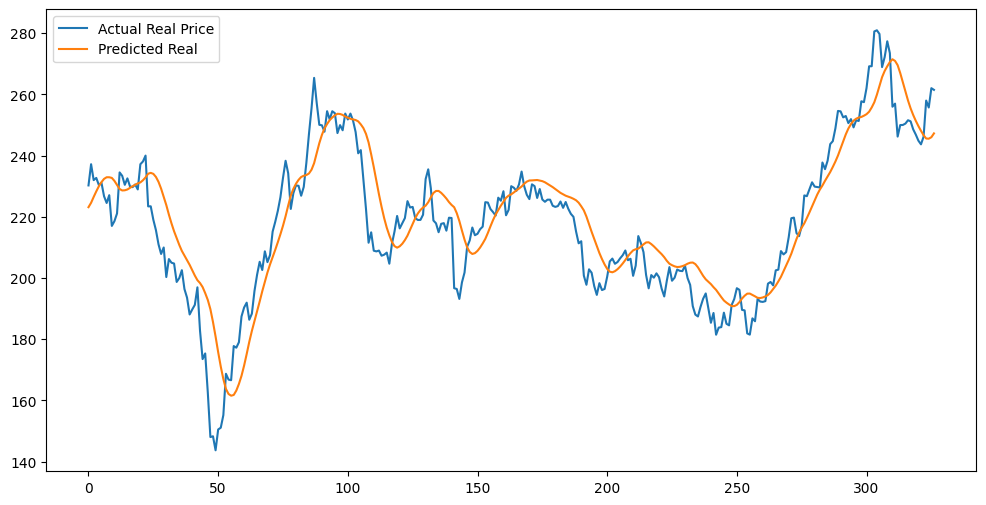

In [37]:
real = df['Close'].values[-len(y_test):]

plt.figure(figsize=(12,6))
plt.plot(real, label='Actual Real Price')
plt.plot(scaler.inverse_transform(y_pred), label='Predicted Real')
plt.legend()
plt.show()

In [73]:
from sklearn.preprocessing import MinMaxScaler

data = df[['Close']].values

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [74]:
print(scaled_data.min(), scaled_data.max())

0.0 1.0


In [75]:
import numpy as np

sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

In [76]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60,1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

In [78]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
41/41 [==============================] - 12s 93ms/step - loss: 0.0270
Epoch 2/20
41/41 [==============================] - 3s 63ms/step - loss: 0.0016
Epoch 3/20
41/41 [==============================] - 2s 58ms/step - loss: 0.0015
Epoch 4/20
41/41 [==============================] - 3s 61ms/step - loss: 0.0014
Epoch 5/20
41/41 [==============================] - 2s 53ms/step - loss: 0.0014
Epoch 6/20
41/41 [==============================] - 2s 54ms/step - loss: 0.0013
Epoch 7/20
41/41 [==============================] - 2s 56ms/step - loss: 0.0013
Epoch 8/20
41/41 [==============================] - 2s 55ms/step - loss: 0.0012
Epoch 9/20
41/41 [==============================] - 2s 53ms/step - loss: 0.0012
Epoch 10/20
41/41 [==============================] - 2s 49ms/step - loss: 0.0011
Epoch 11/20
41/41 [==============================] - 2s 47ms/step - loss: 0.0011
Epoch 12/20
41/41 [==============================] - 2s 51ms/step - loss: 0.0010
Epoch 13/20
41/41 [=================

In [79]:
y_pred = model.predict(X_test)

11/11 [==============================] - 3s 21ms/step


In [80]:
y_test_actual = scaler.inverse_transform(y_test)
y_pred_actual = scaler.inverse_transform(y_pred)

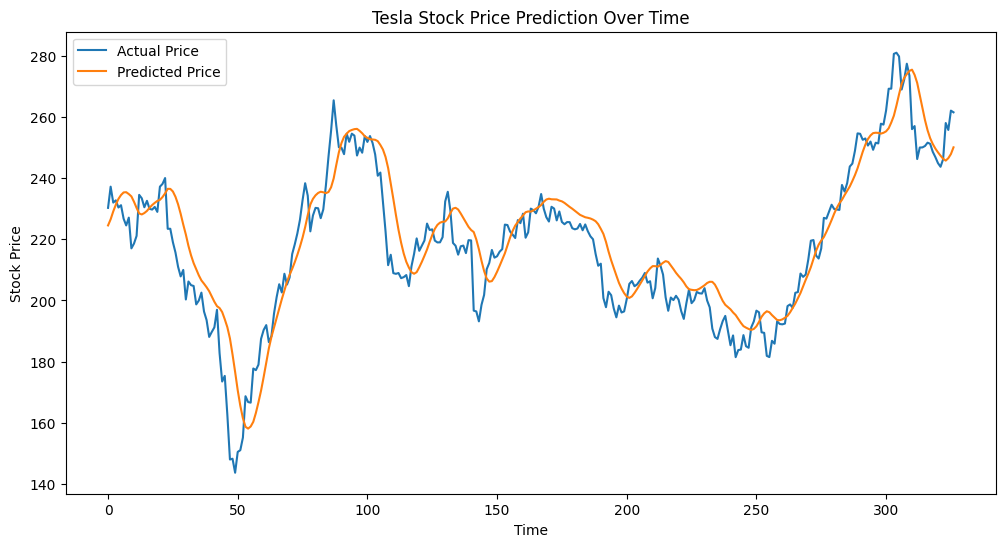

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(y_pred_actual, label="Predicted Price")

plt.title("Tesla Stock Price Prediction Over Time")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()
plt.show()